In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.cluster import KMeans





sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


In [54]:
# Load datasets
sentiment_df = pd.read_csv("fear_greed_index.csv")
trades_df = pd.read_csv("historical_data (1).csv")

print("Sentiment Shape:", sentiment_df.shape)
print("Trades Shape:", trades_df.shape)


Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [55]:
sentiment_df.head(), trades_df.head()


(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03
 3  1517722200     24   Extreme Fear  2018-02-04
 4  1517808600     11   Extreme Fear  2018-02-05,
                                       Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY 

In [56]:
print("Sentiment Missing Values:\n", sentiment_df.isna().sum())
print("\nTrades Missing Values:\n", trades_df.isna().sum())

print("\nSentiment Duplicates:", sentiment_df.duplicated().sum())
print("Trades Duplicates:", trades_df.duplicated().sum())


Sentiment Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Duplicates: 0
Trades Duplicates: 0


In [64]:
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()
trades_df.columns = trades_df.columns.str.strip().str.lower()
# Sentiment timestamp (already daily, but normalize)
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"]).dt.date

# Trade timestamp (milliseconds → datetime)
trades_df["timestamp"] = pd.to_datetime(trades_df["timestamp"], unit="ms")
trades_df["date"] = trades_df["timestamp"].dt.date


In [63]:
merged_df = trades_df.merge(
    sentiment_df[["date", "classification"]],
    on="date",
    how="inner"
)


In [65]:
print("Merged shape:", merged_df.shape)
print("\nSentiment distribution:")
print(merged_df["classification"].value_counts())

merged_df.head()


Merged shape: (184263, 18)

Sentiment distribution:
classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [68]:
# Rename columns ONCE for sanity (recommended)
merged_df = merged_df.rename(columns={
    "closed pnl": "closed_pnl",
    "size usd": "size_usd",
    "execution price": "execution_price",
    "size tokens": "size_tokens"
})

# Win / Loss
merged_df["win"] = merged_df["closed_pnl"] > 0

# Trade size (USD)
merged_df["abs_size_usd"] = merged_df["size_usd"].abs()

# Long / Short
merged_df["is_long"] = merged_df["side"].str.lower().isin(["buy", "long"])



In [69]:
daily_metrics = merged_df.groupby(
    ["account", "date", "classification"]
).agg(
    daily_pnl=("closed_pnl", "sum"),
    trades=("closed_pnl", "count"),
    win_rate=("win", "mean"),
    avg_trade_size_usd=("abs_size_usd", "mean"),
    long_ratio=("is_long", "mean")
).reset_index()

daily_metrics.head()


,account,date,classification,daily_pnl,trades,win_rate,avg_trade_size_usd,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,Greed,-3.275059e+05,462,0.025974,14810.891818,0.300866
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,Fear,1.927736e+06,3356,0.405542,16345.241940,0.468415
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,Greed,2.060745e+04,320,0.531250,2492.749906,0.453125
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,Fear,1.709873e+04,3533,0.435041,1693.351684,0.432494
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,Neutral,-1.000000e+00,5,0.000000,6070.200000,0.400000


In [70]:
performance_summary = daily_metrics.groupby("classification").agg(
    avg_pnl=("daily_pnl", "mean"),
    median_pnl=("daily_pnl", "median"),
    avg_win_rate=("win_rate", "mean"),
    avg_trades=("trades", "mean")
)

performance_summary


,avg_pnl,median_pnl,avg_win_rate,avg_trades
classification,,,,
Extreme Greed,35393.098355,0.000000,0.336609,1392.40000
Fear,209372.662205,81389.682515,0.415878,4183.46875
Greed,99675.516731,35988.376437,0.374074,1134.03125
Neutral,19842.797260,-0.418640,0.260683,892.62500


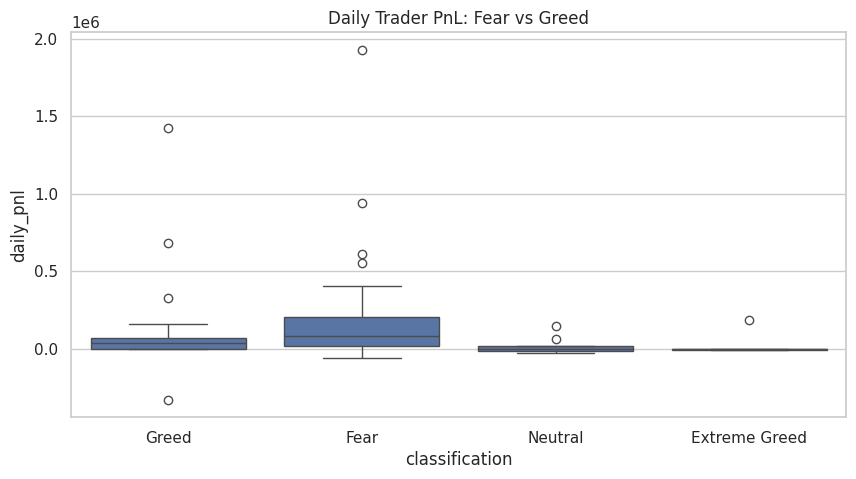

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=daily_metrics,
    x="classification",
    y="daily_pnl"
)
plt.title("Daily Trader PnL: Fear vs Greed")
plt.show()


In [72]:
behavior_summary = daily_metrics.groupby("classification").agg(
    avg_trade_size_usd=("avg_trade_size_usd", "mean"),
    trade_frequency=("trades", "mean"),
    long_bias=("long_ratio", "mean")
)

behavior_summary



,avg_trade_size_usd,trade_frequency,long_bias
classification,,,
Extreme Greed,4344.447836,1392.40000,0.518479
Fear,5926.522723,4183.46875,0.459352
Greed,5839.310974,1134.03125,0.495780
Neutral,3793.444161,892.62500,0.468967


In [73]:
daily_metrics["frequency_segment"] = np.where(
    daily_metrics["trades"] > daily_metrics["trades"].median(),
    "Frequent",
    "Infrequent"
)

daily_metrics.groupby(
    ["classification", "frequency_segment"]
)["daily_pnl"].mean()


classification  frequency_segment
Extreme Greed   Frequent              95224.489473
                Infrequent            -4494.495724
Fear            Frequent             265107.235726
                Infrequent            42168.941645
Greed           Frequent             281689.454396
                Infrequent            28452.671557
Neutral         Frequent               9156.505979
                Infrequent            26254.572028
Name: daily_pnl, dtype: float64

In [74]:
trader_volatility = daily_metrics.groupby("account")["daily_pnl"].std().reset_index()
trader_volatility.columns = ["account", "pnl_volatility"]

daily_metrics = daily_metrics.merge(trader_volatility, on="account")

daily_metrics["consistency"] = np.where(
    daily_metrics["pnl_volatility"] < daily_metrics["pnl_volatility"].median(),
    "Consistent",
    "Inconsistent"
)

daily_metrics.groupby(
    ["classification", "consistency"]
)["daily_pnl"].mean()


classification  consistency 
Extreme Greed   Consistent       -5564.016140
                Inconsistent     45632.376978
Fear            Consistent       31376.268105
                Inconsistent    366428.304059
Greed           Consistent       30104.373752
                Inconsistent    178522.812106
Neutral         Consistent       -5853.977069
                Inconsistent     45539.571589
Name: daily_pnl, dtype: float64

In [75]:
# Use avg trade size as leverage proxy
daily_metrics["leverage_proxy"] = daily_metrics["avg_trade_size_usd"]

# Median split
median_leverage = daily_metrics["leverage_proxy"].median()

daily_metrics["leverage_segment"] = np.where(
    daily_metrics["leverage_proxy"] > median_leverage,
    "High Leverage (Proxy)",
    "Low Leverage (Proxy)"
)


In [76]:
leverage_performance = daily_metrics.groupby(
    ["classification", "leverage_segment"]
).agg(
    avg_pnl=("daily_pnl", "mean"),
    median_pnl=("daily_pnl", "median"),
    avg_win_rate=("win_rate", "mean"),
    avg_trades=("trades", "mean")
)

leverage_performance


avg_pnl    median_pnl  \
classification leverage_segment                                     
Extreme Greed  High Leverage (Proxy)   44241.372943  -1478.560692   
               Low Leverage (Proxy)        0.000000      0.000000   
Fear           High Leverage (Proxy)  284460.190407  99385.807941   
               Low Leverage (Proxy)   112831.554518  43286.083101   
Greed          High Leverage (Proxy)   35305.626196  20925.513222   
               Low Leverage (Proxy)   143718.073412  37526.331877   
Neutral        High Leverage (Proxy)  -13499.337363 -14505.505750   
               Low Leverage (Proxy)    39848.078033    215.754798   

                                      avg_win_rate   avg_trades  
classification leverage_segment                                  
Extreme Greed  High Leverage (Proxy)      0.420761  1718.500000  
               Low Leverage (Proxy)       0.000000    88.000000  
Fear           High Leverage (Proxy)      0.404955  3302.277778  
               Low Leverage (Proxy)       0.429923  5316.428571  
Greed          High Leverage (Proxy)      0.385415   402.538462  
               Low Leverage (Proxy)       0.366315  1634.526316  
Neutral        High Leverage (Proxy)      0.110517   451.000000  
               Low Leverage (Proxy)       0.350783  1157.600000

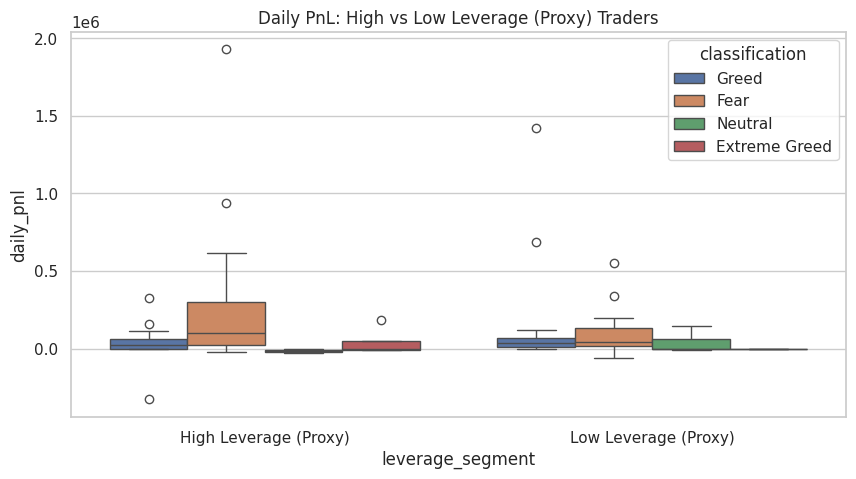

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=daily_metrics,
    x="leverage_segment",
    y="daily_pnl",
    hue="classification"
)

plt.title("Daily PnL: High vs Low Leverage (Proxy) Traders")
plt.show()



In [79]:
# Binary target: profitable day or not
daily_metrics["profitable"] = (daily_metrics["daily_pnl"] > 0).astype(int)

# Encode sentiment, handling unmapped classifications with -1
daily_metrics["sentiment_encoded"] = daily_metrics["classification"].map({
    "Fear": 0,
    "Greed": 1
}).fillna(-1).astype(int)

# Feature set
features = [
    "avg_trade_size_usd",
    "trades",
    "long_ratio",
    "sentiment_encoded"
]

X = daily_metrics[features]
y = daily_metrics["profitable"]

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [85]:

model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.80      1.00      0.89        16

    accuracy                           0.80        20
   macro avg       0.40      0.50      0.44        20
weighted avg       0.64      0.80      0.71        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [87]:
trader_features = daily_metrics.groupby("account").agg(
    avg_trade_size_usd=("avg_trade_size_usd", "mean"),
    avg_trades_per_day=("trades", "mean"),
    long_ratio=("long_ratio", "mean"),
    pnl_volatility=("pnl_volatility", "mean"),
    avg_daily_pnl=("daily_pnl", "mean")
).dropna()

trader_features.head()


,avg_trade_size_usd,avg_trades_per_day,long_ratio,pnl_volatility,avg_daily_pnl
account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,15578.066879,1909.0,0.384640,1.594697e+06,800114.909989
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2093.050795,1926.5,0.442809,2.481039e+03,18853.086574
0x271b280974205ca63b716753467d5a371de622ab,16282.920323,382.0,0.481808,1.681032e+04,10587.696144
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,508.413964,6633.0,0.503793,7.880372e+04,66157.740843
0x2c229d22b100a7beb69122eed721cee9b24011dd,3073.413160,1617.0,0.376316,4.539380e+04,84313.992027


In [88]:
scaler = StandardScaler()
trader_scaled = scaler.fit_transform(trader_features)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features["cluster"] = kmeans.fit_predict(trader_scaled)

trader_features.head()


,avg_trade_size_usd,avg_trades_per_day,long_ratio,pnl_volatility,avg_daily_pnl,cluster
account,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,15578.066879,1909.0,0.384640,1.594697e+06,800114.909989,2
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2093.050795,1926.5,0.442809,2.481039e+03,18853.086574,0
0x271b280974205ca63b716753467d5a371de622ab,16282.920323,382.0,0.481808,1.681032e+04,10587.696144,1
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,508.413964,6633.0,0.503793,7.880372e+04,66157.740843,0
0x2c229d22b100a7beb69122eed721cee9b24011dd,3073.413160,1617.0,0.376316,4.539380e+04,84313.992027,0


In [89]:
cluster_summary = trader_features.groupby("cluster").mean()
cluster_summary


,avg_trade_size_usd,avg_trades_per_day,long_ratio,pnl_volatility,avg_daily_pnl
cluster,,,,,
0,3009.396129,2500.771739,0.475129,1.034241e+05,90558.524387
1,13424.538548,1577.150000,0.536534,1.942111e+05,167554.017636
2,15578.066879,1909.000000,0.384640,1.594697e+06,800114.909989
